# Language Models for Text Classification with the AG News Dataset — Student Version

In this notebook, you will progressively build a small prompting-based text classification pipeline with the **AG News** dataset.

## Learning goals
- load and inspect a text classification dataset
- design **zero-shot** and **few-shot** prompts
- query **two LLM APIs** (**Groq** and **Mistral**)
- normalize model outputs
- evaluate predictions on a small test subset
- reflect on strengths and limitations of prompting for classification


## 1. Setup

This notebook should use:
- `datasets` for AG News
- `pandas` and `matplotlib` for quick inspection
- `groq` for one API
- `mistralai` for a second API

> Keep API keys out of the notebook when possible.

In [246]:
# TODO: uncomment and run if needed
!pip install -q datasets pandas matplotlib groq mistralai

In [247]:
import os
import re
import json
import random
import time
from typing import List, Dict, Optional

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from openai import OpenAI
from groq import Groq

In [ ]:
SEED = 42

# TODO: set the random seed
import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)

# Small subsets keep the demo fast and avoid exhausting free quotas.
TRAIN_SUBSET = 24
TEST_SUBSET = 20

LABELS = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech",
}

# TODO:
# 1) set your API keys in the environment before running
# 2) read them with os.getenv(...)
# 3) print a quick check (True / False)

# Example in a terminal:
# export GROQ_API_KEY="..."
# export MISTRAL_API_KEY="..."

# GROQ_API_KEY = ...
# MISTRAL_API_KEY = ...
GROQ_API_KEY = "gsk_egxYC5mnZYmU68AThMEsFWXawpP9QzLL3X"
MISTRAL_API_KEY = "HspvINF6ezqOVVWXsi0"

# GROQ_MODEL = ...
# MISTRAL_MODEL = ...
GROQ_MODEL = "llama-3.1-8b-instant"       # No ficheiro .py usamos: llama-3.3-70b-versatile   # dado pelo GPT: llama3-8b-8192
MISTRAL_MODEL = "mistral-small"

print("Groq key loaded:", bool(GROQ_API_KEY))
print("Mistral key loaded:", bool(MISTRAL_API_KEY))

Groq key loaded: True
Mistral key loaded: True


## 2. Load and inspect AG News

AG News contains four topic classes:
1. World
2. Sports
3. Business
4. Sci/Tech

Each example contains a piece of text and a numeric label.

In [249]:
print("Loading AG News...")
dataset = load_dataset("ag_news")

train_data = dataset["train"].shuffle(seed=SEED)
test_data = dataset["test"].shuffle(seed=SEED)

if TRAIN_SUBSET is not None:
    train_data = train_data.select(range(TRAIN_SUBSET))
if TEST_SUBSET is not None:
    test_data = test_data.select(range(TEST_SUBSET))

print(dataset)
print("Train subset size:", len(train_data))
print("Test subset size:", len(test_data))

Loading AG News...
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Train subset size: 24
Test subset size: 20


In [250]:
# TODO: convert the subsets to pandas DataFrames
# df_train = ...
# df_test = ...
df_train = pd.DataFrame(train_data)
df_test = pd.DataFrame(test_data)

# TODO: map numeric labels to label names
# df_train["label_name"] = ...
# df_test["label_name"] = ...
df_train["label_name"] = df_train["label"].map(LABELS)
df_test["label_name"] = df_test["label"].map(LABELS)

# TODO: inspect a few rows
# display(...)
# display(...)
display(df_train.head())
display(df_test.head())

,text,label,label_name
0,Bangladesh paralysed by strikes Opposition act...,0,World
1,Desiring Stability Redskins coach Joe Gibbs ex...,1,Sports
2,Will Putin #39;s Power Play Make Russia Safer?...,0,World
3,U2 pitches for Apple New iTunes ads airing dur...,3,Sci/Tech
4,S African TV in beheading blunder Public broad...,0,World


,text,label,label_name
0,Indian board plans own telecast of Australia s...,1,Sports
1,Stocks Higher on Drop in Jobless Claims A shar...,2,Business
2,"Nuggets 112, Raptors 106 Carmelo Anthony score...",1,Sports
3,Stocks Higher on Drop in Jobless Claims A shar...,2,Business
4,REVIEW: 'Half-Life 2' a Tech Masterpiece (AP) ...,3,Sci/Tech


Counter({3: 8, 2: 7, 0: 5, 1: 4})


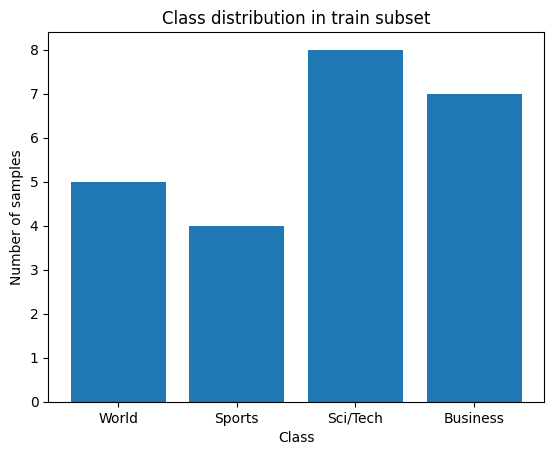

In [251]:
# TODO: plot the class distribution in the train subset

# Your code here

from collections import Counter
import matplotlib.pyplot as plt

label_counts = Counter(df_train["label"]) # df_train["label"]).items()
print(label_counts)

classes = [LABELS[i] for i in label_counts.keys()]
counts = list(label_counts.values())

plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Class distribution in train subset")
plt.show()

## 3. Build prompts

We want the model to return **only one** of these labels:
- `World`
- `Sports`
- `Business`
- `Sci/Tech`

### TODOs
- understand why constrained output matters
- compare **zero-shot** and **few-shot**
- decide what makes a good support example

In [252]:
def format_example(example):
    # TODO:
    # return a formatted string version of one AG News example
    # You may include:
    # - the title
    # - the full text
    # Keep the format simple and consistent.

    title = example["title"]
    text = example["text"]

    formatted = f"Title: {title}\nText: {text}"
    
    return formatted

In [253]:
def build_zero_shot_prompt(example):
    # TODO:
    # create a prompt that:
    # 1) tells the model it is a news classifier
    # 2) lists the four possible labels
    # 3) asks for exactly one label
    # 4) includes the news example
    # 5) avoids explanations in the answer
    prompt = f"""
You are a news classifier.

Classify the following news article into ONE of the following categories:
World
Sports
Business
Sci/Tech

Return ONLY the category name. Do not explain.

News:
{example['text']}

Answer:
"""
    return prompt.strip()

In [254]:
def build_few_shot_prompt(example, support_examples):
    # TODO:
    # create a few-shot prompt using support examples
    #
    # Requirements:
    # - reuse the same instruction style as zero-shot
    # - include labeled examples before the test item
    # - keep formatting identical across examples
    # - finish with the unlabeled target example
    #
    # Optional challenge:
    # - try 1 example per class
    # - later try 2 examples per class
    
    support_block = ""

    # construir exemplos de suporte
    for ex in support_examples:
        support_block += f"""
Title: {ex['title']}
Text: {ex['text']}
Label: {LABELS[ex['label']]}
"""

    prompt = f"""
You are a news classifier.

Classify the following news article into ONE of the following categories:
World
Sports
Business
Sci/Tech

Return ONLY the category name. Do not explain.

Examples:
{support_block}

Now classify this article:

{example['text']}

Answer:
"""
    return prompt.strip()

## 4. API helpers

We will compare:
1. **Groq**
2. **Mistral**

Both functions should receive a prompt and return the model's raw text output.

In [255]:
# TODO: initialize the Groq client

from groq import Groq

# initialize client
# groq_client = ...
groq_client = Groq(api_key=GROQ_API_KEY)

def ask_groq(prompt, model=GROQ_MODEL):
    # TODO:
    # complete the API call
    # Hints:
    # - use a chat completion
    # - pass the prompt as a user message
    # - use temperature=0 for deterministic behavior
    # - keep max_tokens small

    response = groq_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0,
        max_tokens=10
    )

    return response.choices[0].message.content.strip()

In [256]:
# from mistralai import Mistral
from mistralai.client import MistralClient
from mistralai.models.chat_completion import ChatMessage

In [257]:
# TODO: initialize the Mistral client

from urllib import response

from mistralai.client import MistralClient
from mistralai.models.chat_completion import ChatMessage

# initialize client
# mistral_client = ...
mistral_client = MistralClient(api_key=MISTRAL_API_KEY)

def ask_mistral(prompt, model=MISTRAL_MODEL):
    # TODO:
    # complete the API call using the official Mistral client
    # Hints:
    # - use client.chat.complete(...)
    # - pass one user message
    # - keep the answer short

    response = mistral_client.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=10,
    )
    
    return response.choices[0].message.content.strip()



In [258]:
VALID_LABELS = set(LABELS.values())

def normalize_prediction(text):
    # TODO:
    # convert a raw model answer into one of the valid labels or None
    #
    # Suggested steps:
    # 1) handle None
    # 2) strip whitespace
    # 3) check exact match
    # 4) fallback: search for one valid label inside a longer sentence

    # 1) handle None
    if text is None:
        return None

    # 2) remove espaços extra
    text = text.strip()

    # 3) exact match
    if text in VALID_LABELS:
        return text

    # 4) procurar label dentro de frase maior
    for label in VALID_LABELS:
        if label.lower() in text.lower():
            return label

    return None

In [259]:
import pandas as pd

def evaluate_predictions(predictions, gold_ids):
    # TODO:
    # return a DataFrame with:
    # - gold_id
    # - gold_label
    # - prediction
    # - correct (True/False)

    rows = []

    # TODO: fill rows
    for pred, gold_id in zip(predictions, gold_ids):

        gold_label = LABELS[gold_id]
        correct = pred == gold_label

        rows.append({
            "gold_id": gold_id,
            "gold_label": gold_label,
            "prediction": pred,
            "correct": correct
        })

    return pd.DataFrame(rows)

## 5. Zero-shot classification

In zero-shot prompting, the model gets **instructions only**, with **no labeled examples**.

### TODOs
- test each API on a very small subset first
- inspect the raw outputs
- check whether the model respects the required format

In [260]:
import time

def run_experiment(
    dataset_split,
    ask_fn,
    prompt,
    support_examples=None,
    sleep_seconds=0.0,
):
    predictions = []
    raw_outputs = []

    for example in dataset_split:
        # TODO:
        # - build the prompt
        # - call the API
        # - normalize the answer
        # - store both raw and normalized outputs
        # - handle errors with try/except
        # raw = ...
        # pred = ...

        if support_examples is None:
            prompt_text = prompt(example)
        else:
            prompt_text = prompt(example, support_examples)

        # chamar API
        # raw = ask_fn(prompt)
        # raw = ask_fn(prompt(example))
        raw = ask_fn(prompt_text)

        # normalizar resposta
        pred = normalize_prediction(raw)

        raw_outputs.append(raw)
        predictions.append(pred)

        # TODO: optional pause to respect rate limits
        # time.sleep(...)
        if sleep_seconds > 0:
            time.sleep(sleep_seconds)
        
    return predictions, raw_outputs

In [261]:
# TODO:
# 1) create a tiny test slice (for example, 5 items)
# 2) extract the gold labels
# 3) run zero-shot with Groq
# 4) run zero-shot with Mistral
# 5) display evaluation tables
# 6) print the raw outputs to inspect formatting

# tiny_test = ...
# gold_tiny = ...

# 1) criar pequeno subconjunto de teste
# tiny_test = list(df_test)[:5]
# tiny_test = df_test[:5]
tiny_test = df_test[:5].to_dict(orient="records")

# 2) extrair labels verdadeiras
# gold_tiny = [example["label"] for example in tiny_test]
gold_tiny = [example["label"] for example in tiny_test]


# 3) zero-shot Groq
# zs_groq_preds, zs_groq_raw = ...
zs_groq_preds, zs_groq_raw = run_experiment(
    tiny_test,
    ask_fn=ask_groq,
    prompt=build_zero_shot_prompt
)

# 4) zero-shot Mistral
# zs_mistral_preds, zs_mistral_raw = ...
zs_mistral_preds, zs_mistral_raw = run_experiment(
    tiny_test,
    ask_fn=ask_mistral,
    prompt=build_zero_shot_prompt
)

# 5) mostrar tabelas de avaliação
groq_eval = evaluate_predictions(zs_groq_preds, gold_tiny)
mistral_eval = evaluate_predictions(zs_mistral_preds, gold_tiny)

# display(...)
# display(...)
display(groq_eval)
display(mistral_eval)

# 6) mostrar respostas cruas do modelo
# print("Groq raw outputs:", ...)
# print("Mistral raw outputs:", ...)
print("Groq raw outputs:", zs_groq_raw)
print("Mistral raw outputs:", zs_mistral_raw)

,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True


,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True


Groq raw outputs: ['Sports', 'Business', 'Sports', 'Business', 'Sci/Tech']
Mistral raw outputs: ['Sports', 'Business', 'Sports', 'Business', 'Sci/Tech']


## 6. Few-shot classification

In few-shot prompting, we include a small number of labeled examples in the prompt.

### TODOs
- build a support set
- start with **one example per class**
- later try more examples
- reflect on whether support example choice changes the results

In [262]:
# TODO:
# create a support set from the training subset
#
# Suggested strategy:
# - pick one example for each label
# - store them in support_examples
# - verify that all 4 labels are covered

support_examples = []
seen = set()

# Your code here

# for ex in support_examples:
for ex in tiny_test:
    # TODO: print the label name and formatted example
    # print(...)
    label_id = ex["text"]
    label__id = ex["label"]
    # print(f"Label: {LABELS[label_id]}")
    print(f"Label: {label_id}")
    print(f"Label ID: {label__id}")
    # print(...)
    # print(format_example(ex))
    print("-" * 80)

Label: Indian board plans own telecast of Australia series The Indian cricket board said on Wednesday it was making arrangements on its own to broadcast next month #39;s test series against Australia, which is under threat because of a raging TV rights dispute.
Label ID: 1
--------------------------------------------------------------------------------
Label: Stocks Higher on Drop in Jobless Claims A sharp drop in initial unemployment claims and bullish forecasts from Nokia and Texas Instruments sent stocks slightly higher in early trading Thursday.
Label ID: 2
--------------------------------------------------------------------------------
Label: Nuggets 112, Raptors 106 Carmelo Anthony scored 30 points and Kenyon Martin added 24 points and 16 rebounds, helping the Denver Nuggets hold off the Toronto Raptors 112-106 Wednesday night.
Label ID: 1
--------------------------------------------------------------------------------
Label: Stocks Higher on Drop in Jobless Claims A sharp drop i

In [263]:
# TODO:
# run few-shot classification on the full test subset with both APIs

# 1) labels verdadeiras
# gold_test = ...
gold_test = [example["label"] for example in tiny_test]

# 2) few-shot Groq
# fs_groq_preds, fs_groq_raw = ...
fs_groq_preds, fs_groq_raw = run_experiment(
    tiny_test,
    ask_fn=ask_groq,
    prompt=build_few_shot_prompt,
    support_examples=support_examples
)

# 3) few-shot Mistral
# fs_mistral_preds, fs_mistral_raw = ...
fs_mistral_preds, fs_mistral_raw = run_experiment(
    tiny_test,
    ask_fn=ask_mistral,
    prompt=build_few_shot_prompt,
    support_examples=support_examples
)

# 4) avaliação
# df_fs_groq = ...
# df_fs_mistral = ...
df_fs_groq = evaluate_predictions(fs_groq_preds, gold_test)
df_fs_mistral = evaluate_predictions(fs_mistral_preds, gold_test)

# 5) mostrar resultados
# display(...)
# display(...)
display(df_fs_groq)
display(df_fs_mistral)

,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True


,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True


## 7. Compare zero-shot vs few-shot

You should now have four settings:
- Groq zero-shot
- Groq few-shot
- Mistral zero-shot
- Mistral few-shot

### TODOs
- compute accuracy for each setting
- compare the numbers
- identify at least 2 error cases

In [ ]:
def accuracy(preds, gold_ids):
    # TODO:
    # compute simple accuracy
    return ...

results = {
    # TODO: fill this dictionary with the four accuracies
    # "Groq zero-shot": ...,
    # "Groq few-shot": ...,
    # "Mistral zero-shot": ...,
    # "Mistral few-shot": ...,
}

results_df = ...
display(results_df)

# TODO: optional bar plot of the four accuracies

,Method,Accuracy
0,Groq zero-shot,1.0
1,Groq few-shot,1.0
2,Mistral zero-shot,1.0
3,Mistral few-shot,1.0


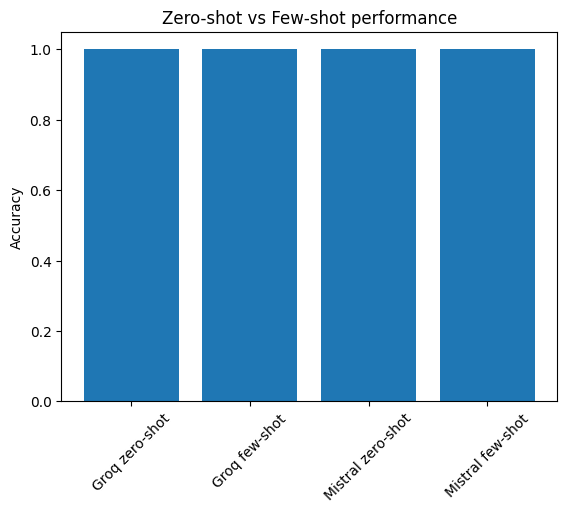

In [265]:
import pandas as pd
import matplotlib.pyplot as plt

def accuracy(preds, gold_ids):
    # TODO:
    # compute simple accuracy
    correct = 0
    total = len(gold_ids)

    for pred, gold_id in zip(preds, gold_ids):
        if pred == LABELS[gold_id]:
            correct += 1

    return correct / total


# calcular accuracies
results = {
    # TODO: fill this dictionary with the four accuracies
    # "Groq zero-shot": ...,
    # "Groq few-shot": ...,
    # "Mistral zero-shot": ...,
    # "Mistral few-shot": ...,
    "Groq zero-shot": accuracy(zs_groq_preds, gold_test),
    "Groq few-shot": accuracy(fs_groq_preds, gold_test),
    "Mistral zero-shot": accuracy(zs_mistral_preds, gold_test),
    "Mistral few-shot": accuracy(fs_mistral_preds, gold_test),
}

# criar DataFrame
# results_df = ...
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Method", "Accuracy"]
)

# display(results_df)
display(results_df)

# TODO: optional bar plot of the four accuracies
# gráfico de comparação
plt.bar(results_df["Method"], results_df["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Zero-shot vs Few-shot performance")
plt.xticks(rotation=45)
plt.show()

## 8. Reflection questions

Answer briefly in your own words.

1. Did few-shot improve performance?
2. Which classes seemed easiest or hardest?
3. Were the outputs always clean and easy to parse?
4. How sensitive were the results to prompt wording?
5. What are the limitations of API-based prompting for classification?
6. When would you prefer a supervised classifier instead?

## 9. Optional extensions

Choose one or more:

- Try **2 support examples per class**
- Compare **headline only** vs **full text**
- Force the model to output a **JSON object**
- Build a **confusion matrix**
- Measure **latency** per API
- Estimate **cost / quota usage**
- Intentionally use **biased support examples** and observe what changes

## 10. Final takeaway

Large language models can perform classification through prompting alone.

### Before finishing, make sure you completed:
- [ ] dataset loading
- [ ] zero-shot prompt
- [ ] few-shot prompt
- [ ] Groq helper
- [ ] Mistral helper
- [ ] normalization
- [ ] evaluation
- [ ] comparison
- [ ] reflection